# Time-Frecuency
*  Jose Gonzalez Lopez
*  Mykola Lyashuha

# Introduction
This is the intro

# Imports

In [1]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise

from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

# Auxiliar Functions

In [ ]:
'''
Signal-to-noise ratio
x: original signal
y: changed(noisy) signal
'''
def snr(x, y):
    return 20*np.log10(np.mean(np.abs(x))/np.mean(np.abs(x-y)))

In [27]:
'''
This function returns the general spectral substraction of a noisy signal
noisy_signal: noisy_signal with short fourier transform
lbda: lambda for formula, parameter we will discuss
power_density_spectrum: estimation of the power spectrum of original signal using welch method
alpha: alpha for formula, parameter we will discuss
beta: beta for formula, parameter we will discuss
gamma: gamma for formula, parameter we will discuss
'''

def spectral_substraction(noisy_signal,power_density_spectrum,lbda,alpha,beta,gamma):
    nsa=np.abs(noisy_signal)**alpha
    pdsa=np.abs(power_density_spectrum)**alpha
    lbdaa=lbda**alpha
    prod=lbdaa*pdsa
    
    if(all(nsa>prod)):
        up=lbdaa*pdsa
        down=nsa
        return noisy_signal*(1-(up/down))
    else:
        return ((gamma*noisy_signal)/(gamma*np.abs(noisy_signal))*np.abs(power_density_spectrum))
        

# Data

In [3]:
samplerate_music, data_music = wavfile.read("music.wav") #Read the file
ipd.Audio(data_music, rate=samplerate_music)

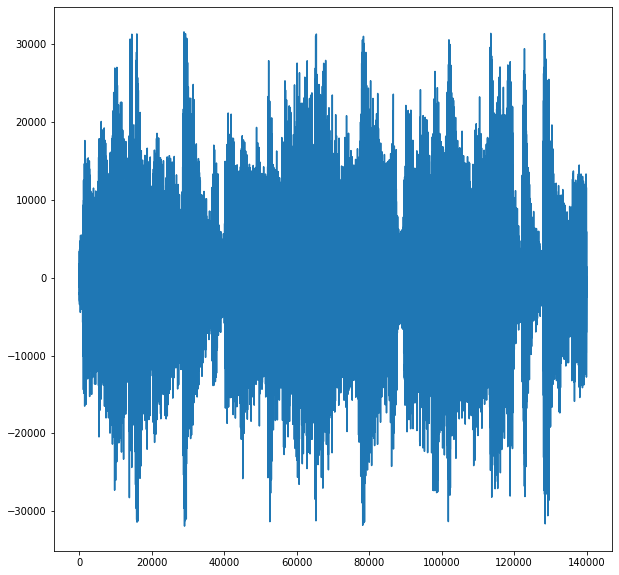

In [4]:
plt.figure(figsize=(10,10))
plt.plot(data_music)

# Noisy versions

In [5]:
stds = [130,70,40, 24,13]
noisy_musics=[]
for std in stds:
    noise = numpy.random.normal(0, 1, size=data_music.shape)
    data_music_noise = data_music + std*noise
    noisy_musics.append(data_music_noise)

# Spectral Substraction

In [28]:
denoised_signals=[]
for data_music_noise in noisy_musics:
    f_stft,t,Zxx=stft(data_music_noise) #Do inverse transform
    f, P_den = welch(data_music_noise, samplerate_music) #Get spectral density
    
    #MMMMMMMMMM
    f_stft+=0.000001
    
    denoised_signal=spectral_substraction(f_stft,P_den,1,2,0.5,0.00001)
    denoised_signals.append(denoised_signal)
    

# Denoising

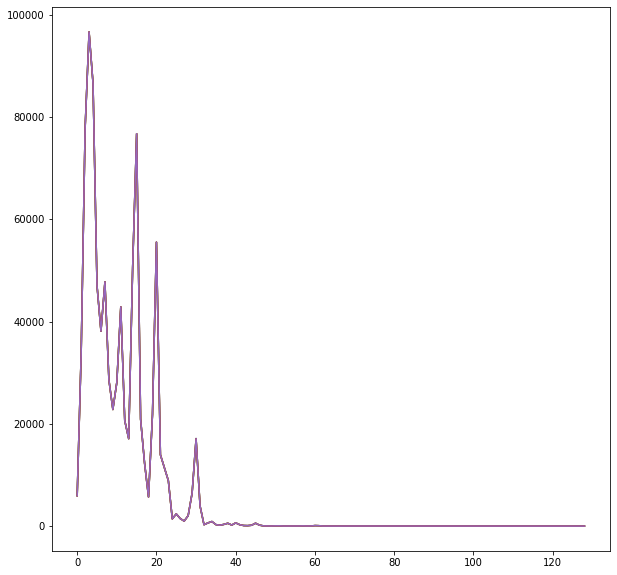

In [32]:
plt.figure(figsize=(10,10))
for denoised_signal in denoised_signals:
    plt.plot(denoised_signal)
    
plt.show()

# Discussion parameters

DISCUSSION

# Conclusions

CONCLUSIONS